# Junction-level LTS Classification (Directed Edge Approach)

This notebook assigns junction-level LTS to each **directed edge** using crossing
stress models derived from the LTN 1/20 Junction Assessment Tool (JAT) and
Table 10-2 (Crossing Design Suitability).

It is the first half of the original notebook 04. It takes the link-level
classified network (`network_lts_classified.gpkg`) and produces the
**junction-enhanced** network (`network_lts_with_junctions.gpkg`), which is then
consumed by `04b_lts_distribution_and_fragmentation.ipynb` for the area-based,
density and fragmentation analysis.

**Directed edge advantage.** Because the network was expanded into directed edges, each edge has a defined travel direction with `from_node` (origin)
and `to_node` (destination). Junction stress is assessed at the `to_node`, the node
a cyclist arrives at, and conflicting traffic is drawn from other directed edges
departing from that same node. This removes the need for separate reachability
filtering based on the `directionality` attribute.

**Two junction models.**

- **Crossing junctions** (priority T-junctions, crossroads): classified by a lookup
  table adapted from LTN 1/20 Table 10-2, using the maximum V85 and AADT of
  conflicting edges departing from the junction node, the approaching edge's
  estimated lane count, and the best available traffic control.
- **Roundabouts**: classified at node level using JAT roundabout-specific criteria.

The final edge LTS = max(link LTS, junction LTS), so junction stress can only
increase, never decrease, an edge's classification.

## 1. Environment and Study Area

In [25]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)       
pd.set_option('display.width', 1000)            
pd.set_option('display.max_colwidth', None) 

import geopandas as gpd

import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon
from shapely import wkt
from shapely.wkt import loads

import contextily as ctx

DATA_DIR = Path('../Data/Raw')
CLEANED_DIR = Path('../Data/Cleaned')
OUTPUT_DIR = Path('../Data/Cleaned')
CRS_BNG = 'EPSG:27700'

pd.set_option('display.max_columns', None)


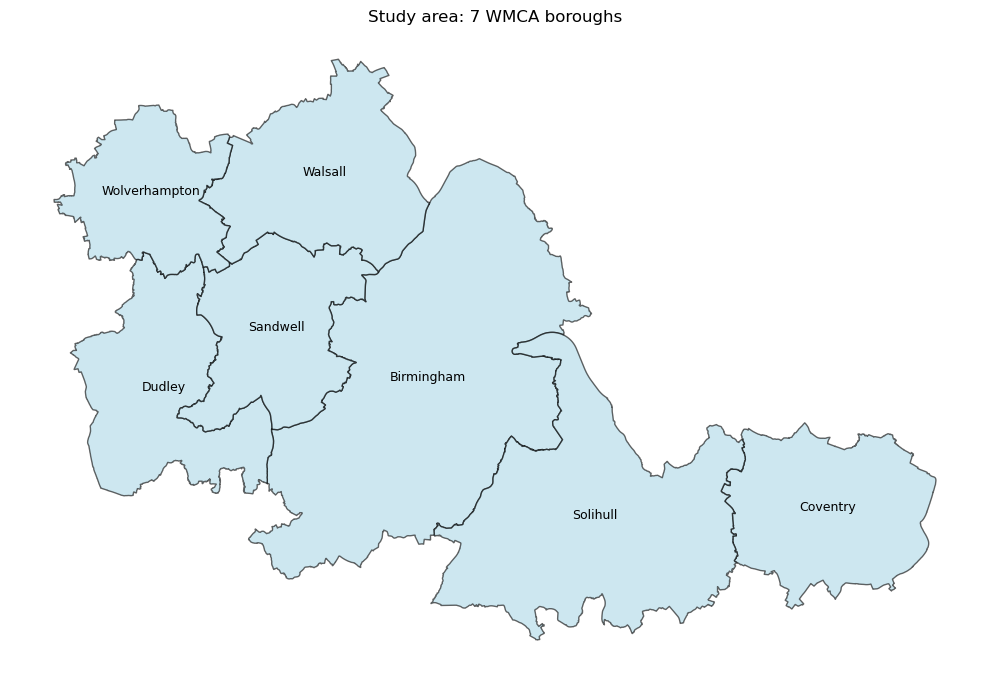


Total study area: 901.7 km²


In [2]:
# Study area boundary
STUDY_AREA_BOROUGHS = [
    'Birmingham',
    'Coventry',
    'Dudley',
    'Sandwell',
    'Solihull',
    'Walsall',
    'Wolverhampton',
]

# Load ONS Local Authority District boundaries
raw_data = gpd.read_file(
    DATA_DIR / "Local_Authority_Districts_DEC_2025_Boundaries_UK_BFC_7781342770234899863/LAD_DEC_2025_UK_BFC.shp"
)

# Filter for WMCA boroughs and reproject to BNG
study_area = raw_data[raw_data['LAD25NM'].isin(STUDY_AREA_BOROUGHS)].copy()
study_area = study_area.to_crs(CRS_BNG)
study_area_union = study_area.unary_union

# Visual check
fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, edgecolor='black', facecolor='lightblue', alpha=0.6)
study_area.apply(lambda r: ax.annotate(
    text=r['LAD25NM'],
    xy=(r.geometry.centroid.x, r.geometry.centroid.y),
    ha='center', fontsize=9
), axis=1)
ax.set_title(f'Study area: {len(STUDY_AREA_BOROUGHS)} WMCA boroughs')
ax.set_axis_off()
plt.tight_layout()
plt.show()

total_area_km2 = study_area.geometry.area.sum() / 1e6
print(f"\nTotal study area: {total_area_km2:.1f} km²")


## 2. Load Link-level Classified Network

Input: `network_lts_classified.gpkg` (link-level LTS from the previous notebook).

In [3]:
network = gpd.read_file(CLEANED_DIR / "network_lts_classified.gpkg")
is_path = network['description'] == 'Path'
network.loc[is_path, 'aadt'] = network.loc[is_path, 'aadt'].fillna(0)
network.loc[is_path, 'est_v85_mph'] = network.loc[is_path, 'est_v85_mph'].fillna(0)
network.loc[is_path, 'roadwidth_average'] = network.loc[is_path, 'roadwidth_average'].fillna(3)
print(f"Network: {len(network):,} directed edges")
print(f"LTS distribution (per edge):")
print(network['lts'].value_counts().sort_index())

roadnode = gpd.read_file(DATA_DIR / "os_datasets/trn_ntwk_roadnode.zip")
pathnode = gpd.read_file(DATA_DIR / "os_datasets/trn_ntwk_pathnode.zip")
print(f"\nRoad Node: {len(roadnode):,} | Path Node: {len(pathnode):,}")


Network: 480,228 directed edges
LTS distribution (per edge):
lts
1.0    325051
2.0     69539
3.0     42465
4.0     43173
Name: count, dtype: int64

Road Node: 191,969 | Path Node: 134,058


## 3. Build Node Table

In [4]:
all_node_ids = set(network['from_node'].unique()) | set(network['to_node'].unique())

rn = roadnode[roadnode['osid'].isin(all_node_ids)][
    ['osid', 'geometry', 'formofroadnode', 'description']
].copy()
rn.columns = ['node_id', 'geometry', 'node_form', 'node_description']

path_only_ids = all_node_ids - set(rn['node_id'])
pn = pathnode[pathnode['osid'].isin(path_only_ids)][['osid', 'geometry']].copy()
pn.columns = ['node_id', 'geometry']
pn['node_form'] = 'Path Node'
pn['node_description'] = 'Path Node'

nodes = pd.concat([rn, pn], ignore_index=True)
nodes['geometry'] = gpd.GeoSeries.from_wkt(nodes['geometry'].astype(str), crs=CRS_BNG)
nodes = gpd.GeoDataFrame(nodes, geometry='geometry', crs=CRS_BNG)
print(f"Node table: {len(nodes):,}")


Node table: 252,915


## 4. Identify Junction Types and Modifiers

- **Roundabout**: `formofroadnode == 'Roundabout'`
- **Mini Roundabout**: `description == 'Mini Roundabout'`
- **Traffic Island**: links with `description == 'Traffic Island Link At Junction'`
- **Traffic Signal**: OpenStreetMap `highway=traffic_signals`, spatially joined
  to the nearest Junction/Roundabout node within 50 m tolerance
- **Segregation facility at roundabout**: roundabout nodes with at least one
  approach edge classified as off-carriageway or cycle track

In [5]:
roundabout_nodes = set(nodes[nodes['node_form'] == 'Roundabout']['node_id'])
mini_roundabout_nodes = set(nodes[nodes['node_description'] == 'Mini Roundabout']['node_id'])

ti_links = network[network['description'] == 'Traffic Island Link At Junction']
ti_node_ids = set(ti_links['from_node'].unique()) | set(ti_links['to_node'].unique())

print(f"Roundabout nodes: {len(roundabout_nodes):,}")
print(f"Mini roundabout nodes: {len(mini_roundabout_nodes):,}")
print(f"Traffic island nodes: {len(ti_node_ids):,}")


Roundabout nodes: 5,759
Mini roundabout nodes: 516
Traffic island nodes: 8,450


In [6]:
# ----- Traffic signals from OSM -----
import osmnx as ox

osm_signals = ox.features_from_place(
    "West Midlands, England",
    tags={"highway": "traffic_signals"}
)
osm_signals = osm_signals[osm_signals.geometry.type == 'Point'].copy()
osm_signals = osm_signals.to_crs(CRS_BNG)
print(f"OSM traffic signal points: {len(osm_signals):,}")

# Only match to actual junction/roundabout nodes
junction_nodes_for_join = nodes[
    nodes['node_form'].isin(['Junction', 'Roundabout'])
][['node_id', 'geometry']].copy().set_index('node_id')

signal_join = gpd.sjoin_nearest(
    osm_signals[['geometry']].reset_index(drop=True),
    junction_nodes_for_join,
    max_distance=50,
    how='inner'
)
signal_nodes = set(signal_join['node_id'].unique())
print(f"Signal nodes matched: {len(signal_nodes):,}")


OSM traffic signal points: 3,907
Signal nodes matched: 2,554


In [7]:
# ----- Segregation facility at roundabout -----
protected_facilities = [
    'Off-Road', 'Shared Use', 'Fully Kerbed Cycle Track',
    'Stepped Cycle Track', 'Light Segregation'
]

rb_approach = network[
    (network['description'] != 'Roundabout') &
    (network['from_node'].isin(roundabout_nodes) | network['to_node'].isin(roundabout_nodes))
]
protected_approaches = rb_approach[rb_approach['facility_type'].isin(protected_facilities)]
rb_nodes_with_segregation = set(
    protected_approaches['from_node'][protected_approaches['from_node'].isin(roundabout_nodes)]
) | set(
    protected_approaches['to_node'][protected_approaches['to_node'].isin(roundabout_nodes)]
)
print(f"Roundabout nodes with segregation facility: {len(rb_nodes_with_segregation):,}")


Roundabout nodes with segregation facility: 474


In [8]:
# ----- Tag nodes -----
nodes['is_roundabout'] = nodes['node_id'].isin(roundabout_nodes)
nodes['is_mini_roundabout'] = nodes['node_id'].isin(mini_roundabout_nodes)
nodes['has_traffic_island'] = nodes['node_id'].isin(ti_node_ids)
nodes['has_signal'] = nodes['node_id'].isin(signal_nodes)
nodes['has_segregation'] = nodes['node_id'].isin(rb_nodes_with_segregation)

print(f"\nNode modifier summary:")
print(f"  Roundabout: {nodes['is_roundabout'].sum():,}")
print(f"  Mini roundabout: {nodes['is_mini_roundabout'].sum():,}")
print(f"  Traffic island: {nodes['has_traffic_island'].sum():,}")
print(f"  Traffic signal: {nodes['has_signal'].sum():,}")
print(f"  Segregation (roundabout): {nodes['has_segregation'].sum():,}")



Node modifier summary:
  Roundabout: 5,759
  Mini roundabout: 516
  Traffic island: 8,426
  Traffic signal: 2,554
  Segregation (roundabout): 474


## 5. Identify Junction Nodes and Compute Edge-level Conflicting Attributes

With directed edges, the junction analysis simplifies significantly. For each
directed edge arriving at a junction (i.e. the edge's `to_node` is a junction),
the conflicting traffic comes from **other directed edges whose `from_node`** is
the same junction — these are the edges a cyclist could potentially conflict with
when crossing through the junction.

This replaces the previous undirected approach which required explicit reachability
filtering via the `directionality` attribute. Directionality is now already encoded
in the edge expansion.

**Steps:**

1. **Compute node degree** from the physical (undirected) link topology to identify
   junction nodes (degree ≥ 3).
2. **For each directed edge arriving at a crossing junction**, find all other edges
   departing from that node (same `from_node`) as conflicting traffic.
3. **Exclude straight-line continuations** (bearing difference ~180° ± 30°).
4. **Extract max V85, max AADT, and lane count** of conflicting edges.

In [9]:
# ----- Identify junction nodes -----
# Degree must reflect physical topology, not directed edge count.
# Deduplicate to original links (one row per osid) to avoid double-counting.
unique_links = network.drop_duplicates('osid')[['osid', 'startnode', 'endnode']]

degree = (unique_links.groupby('startnode').size()
          .add(unique_links.groupby('endnode').size(), fill_value=0).astype(int))
degree.index.name = 'node_id'

if nodes.index.name == 'node_id':
    nodes = nodes.reset_index()

nodes = nodes.set_index('node_id')
nodes['degree'] = degree
nodes = nodes.reset_index()

nodes['is_junction'] = (
    (nodes['degree'] > 2) &
    nodes['node_form'].isin(['Junction', 'Roundabout', 'Path Node']) &
    (nodes['node_description'] != 'Grade Separation')
)

print(f"Junction nodes: {nodes['is_junction'].sum():,}")


Junction nodes: 88,311


In [10]:
# ----- Identify crossing junction nodes (exclude roundabouts) -----
crossing_junction_ids = set(
    nodes[
        nodes['is_junction'] &
        ~nodes['is_roundabout'] &
        ~nodes['is_mini_roundabout']
    ]['node_id']
)
print(f"Crossing junction nodes: {len(crossing_junction_ids):,}")


Crossing junction nodes: 82,628


In [11]:
# ----- Build (edge, junction_node) pairs for crossing junctions -----
# With directed edges, the junction node is simply the edge's to_node:
# the cyclist travels along the edge and arrives at the junction.

cols = ['edge_id', 'osid', 'from_node', 'to_node',
        'aadt', 'est_v85_mph', 'roadwidth_average', 'description']

edge_at_junc = network.loc[
    network['to_node'].isin(crossing_junction_ids), cols
].copy()
edge_at_junc['junction_node'] = edge_at_junc['to_node']

print(f"(edge, junction_node) pairs: {len(edge_at_junc):,}")


(edge, junction_node) pairs: 237,874


In [12]:
# ----- Reachability -----
# With directed edges, reachability is inherent: every edge is traversable
# in its defined direction. No directionality filtering needed.
print(f"All {len(edge_at_junc):,} (edge, junction) pairs are reachable by definition.")
print("(Directionality already encoded in Notebook 00 edge expansion.)")


All 237,874 (edge, junction) pairs are reachable by definition.
(Directionality already encoded in Notebook 00 edge expansion.)


In [13]:
# ----- Compute bearing of each edge at its junction node (to_node) -----
def compute_bearing_at_to_node(geom, n_points=3):
    """
    Compute the bearing of a directed edge at its to_node (arrival end).
    Uses the last n_points of the geometry to get the approach direction,
    then flips 180° so the bearing points AWAY from the junction.
    """
    coords = list(geom.coords)
    seg = coords[-n_points:]
    dx = seg[-1][0] - seg[0][0]
    dy = seg[-1][1] - seg[0][1]
    bearing = (np.degrees(np.arctan2(dx, dy))) % 360
    # Flip: raw bearing points towards junction, we want away from it
    return (bearing + 180) % 360


# Build geometry lookup (one per osid, since fwd/bwd share geometry)
geom_lookup = network.drop_duplicates('osid').set_index('osid')['geometry']

# For backward edges the geometry is not reversed, so we need to handle
# the bearing differently: use first n_points instead of last.
def compute_bearing_for_edge(row, n_points=3):
    geom = geom_lookup[row['osid']]
    coords = list(geom.coords)
    edge_dir = network.loc[network['edge_id'] == row['edge_id'], 'edge_dir'].iloc[0]
    
    if edge_dir == 'forward':
        # Arriving at to_node = endnode → use last n_points
        seg = coords[-n_points:]
    else:
        # Backward edge: arriving at to_node = startnode → use first n_points
        seg = coords[:n_points]
        # Reverse segment so it points towards the junction
        seg = seg[::-1]
    
    dx = seg[-1][0] - seg[0][0]
    dy = seg[-1][1] - seg[0][1]
    bearing = (np.degrees(np.arctan2(dx, dy))) % 360
    # Flip: raw bearing points towards junction, we want away
    return (bearing + 180) % 360


# Pre-build edge_dir lookup for speed
_edge_dir_map = network.set_index('edge_id')['edge_dir'].to_dict()

def compute_bearing_fast(row, n_points=3):
    geom = geom_lookup[row['osid']]
    coords = list(geom.coords)
    edge_dir = _edge_dir_map[row['edge_id']]
    
    if edge_dir == 'forward':
        seg = coords[-n_points:]
    else:
        seg = coords[:n_points][::-1]
    
    dx = seg[-1][0] - seg[0][0]
    dy = seg[-1][1] - seg[0][1]
    bearing = (np.degrees(np.arctan2(dx, dy))) % 360
    return (bearing + 180) % 360


edge_at_junc['bearing_at_junc'] = edge_at_junc.apply(compute_bearing_fast, axis=1)
print(f"Bearings computed for {len(edge_at_junc):,} (edge, junction_node) pairs")


# ----- Compute conflicting V85, AADT, and crossing lanes -----
# Conflicting edges: other directed edges whose from_node == this junction node
# (i.e. edges DEPARTING from the junction — traffic the cyclist must cross)

departing_edges = network.loc[
    network['from_node'].isin(crossing_junction_ids),
    ['edge_id', 'osid', 'from_node', 'aadt', 'est_v85_mph', 'roadwidth_average']
].copy()
departing_edges.rename(columns={'from_node': 'junction_node'}, inplace=True)

# Compute bearing of departing edges at their from_node (junction)
def compute_bearing_depart(row, n_points=3):
    geom = geom_lookup[row['osid']]
    coords = list(geom.coords)
    edge_dir = _edge_dir_map[row['edge_id']]
    
    if edge_dir == 'forward':
        # from_node = startnode → use first n_points, bearing away from junction
        seg = coords[:n_points]
    else:
        # from_node = endnode → use last n_points reversed, bearing away from junction
        seg = coords[-n_points:][::-1]
    
    dx = seg[-1][0] - seg[0][0]
    dy = seg[-1][1] - seg[0][1]
    return (np.degrees(np.arctan2(dx, dy))) % 360


departing_edges['bearing_at_junc'] = departing_edges.apply(compute_bearing_depart, axis=1)


# ----- Self-join: match arriving edges with departing edges at same junction -----
merged = edge_at_junc.merge(
    departing_edges,
    on='junction_node',
    suffixes=('', '_other')
)
# Exclude self (same original link in either direction)
merged = merged[merged['osid'] != merged['osid_other']]


# ----- Identify straight-line continuations (bearing diff ~180° ± 30°) -----
def is_straight_continuation(bearing_self, bearing_other, threshold=30):
    diff = abs(bearing_self - bearing_other) % 360
    if diff > 180:
        diff = 360 - diff
    return abs(diff - 180) <= threshold

merged['is_straight_cont'] = merged.apply(
    lambda row: is_straight_continuation(
        row['bearing_at_junc'], row['bearing_at_junc_other']
    ),
    axis=1
)

print(f"Straight-line continuations: {merged['is_straight_cont'].sum():,} "
      f"out of {len(merged):,} conflict pairs")


# ----- Lane estimation -----
def get_lane_category(width):
    if pd.isna(width) or width < 0:
        return 1
    if width <= 6:
        return 1
    elif width <= 9.0:
        return 2
    else:
        return 3

merged['conflict_lanes'] = merged['roadwidth_average_other'].apply(get_lane_category)


# ----- Aggregate: exclude straight-line continuations -----
merged_crossing = merged[~merged['is_straight_cont']]

conflict_attrs = merged_crossing.groupby(['edge_id', 'junction_node']).agg(
    max_conflict_v85=('est_v85_mph_other', 'max'),
    max_conflict_aadt=('aadt_other', 'max'),
    est_lanes=('conflict_lanes', 'max'),
    n_conflict_links=('osid_other', 'nunique')
).reset_index()


# Fallback: if ALL conflicts are straight continuations, use all
all_pairs = merged.groupby(['edge_id', 'junction_node']).agg(
    max_conflict_v85=('est_v85_mph_other', 'max'),
    max_conflict_aadt=('aadt_other', 'max'),
    est_lanes=('conflict_lanes', 'max'),
    n_conflict_links=('osid_other', 'nunique')
).reset_index()

all_keys = merged[['edge_id', 'junction_node']].drop_duplicates()
conflict_keys = conflict_attrs[['edge_id', 'junction_node']]
missing = all_keys.merge(conflict_keys, on=['edge_id', 'junction_node'],
                         how='left', indicator=True)
missing = missing[missing['_merge'] == 'left_only'][['edge_id', 'junction_node']]

if len(missing) > 0:
    fallback_rows = all_pairs.merge(missing, on=['edge_id', 'junction_node'])
    conflict_attrs = pd.concat([conflict_attrs, fallback_rows], ignore_index=True)
    print(f"Fallback applied to {len(missing):,} pairs with only straight-line conflicts")

print(f"\n(edge, junction_node) pairs with conflict data: {len(conflict_attrs):,}")
print(f"\nConflicting links per junction approach:")
print(conflict_attrs['n_conflict_links'].describe().round(1))
print(f"\nCrossing lanes distribution:")
print(conflict_attrs['est_lanes'].value_counts().sort_index())


Bearings computed for 237,874 (edge, junction_node) pairs
Straight-line continuations: 160,135 out of 481,504 conflict pairs
Fallback applied to 9,461 pairs with only straight-line conflicts

(edge, junction_node) pairs with conflict data: 237,872

Conflicting links per junction approach:
count    237872.0
mean          1.4
std           0.5
min           1.0
25%           1.0
50%           1.0
75%           2.0
max           8.0
Name: n_conflict_links, dtype: float64

Crossing lanes distribution:
est_lanes
1     81515
2    101027
3     55330
Name: count, dtype: int64


In [14]:
# ----- Merge node-level modifiers and determine protection -----
node_modifiers = nodes.set_index('node_id')[
    ['has_traffic_island', 'has_signal', 'node_description']
]
conflict_attrs = conflict_attrs.join(node_modifiers, on='junction_node')

# Determine best protection at junction: signal > island > uncontrolled
conflict_attrs['protection'] = 'uncontrolled'
conflict_attrs.loc[conflict_attrs['has_traffic_island'], 'protection'] = 'island'
conflict_attrs.loc[conflict_attrs['has_signal'], 'protection'] = 'signal'

print(f"Protection distribution:")
print(conflict_attrs['protection'].value_counts())
print(f"\nEst. crossing lanes distribution:")
print(conflict_attrs['est_lanes'].value_counts().sort_index())


Protection distribution:
protection
uncontrolled    222801
island            9463
signal            5608
Name: count, dtype: int64

Est. crossing lanes distribution:
est_lanes
1     81515
2    101027
3     55330
Name: count, dtype: int64


## 6. Crossing Junction Classification (Link-level)

Adapted from LTN 1/20 Table 10-2 (Crossing Design Suitability). The lookup now
operates on the **(link, junction node)** conflict attributes computed, rather than on node-level maxima. This means that two links
approaching the same junction may receive different junction LTS scores —
correctly reflecting asymmetric conflict exposure (e.g. a residential side-street
entering a dual carriageway faces higher crossing stress than the through-movement
on the carriageway itself).

**Table: Crossing junction LTS classification**

| V85 (conflicting) | AADT (conflicting) | Lanes (to be crossed) | Uncontrolled | Traffic Island | Signalised |
|---|---|---|---|---|---|
| ≥ 37 mph | any | any | 4 | 4 | 3 |
| 30–37 | > 10,000 | any | 4 | 4 | 1 |
| 30–37 | 6,000–10,000 | ≥ 2 | 4 | 4 | 1 |
| 30–37 | 0–6,000 | ≥ 2 | 3 | 3 | 1 |
| 30–37 | 0–10,000 | 1 | 2 | 2 | 1 |
| ≤ 30 | > 8,000 | > 2 | 4 | 3 | 1 |
| ≤ 30 | > 8,000 | ≤ 2 | 3 | 2 | 1 |
| ≤ 30 | 4,000–8,000 | ≥ 2 | 2 | 2 | 1 |
| ≤ 30 | 4,000–8,000 | 1 | 2 | 1 | 1 |
| ≤ 30 | 0–4,000 | ≥ 2 | 2 | 1 | 1 |
| ≤ 30 | 0–4,000 | 1 | 1 | 1 | 1 |

In [15]:
def classify_crossing_lts(df):
    """
    Classify crossing junction LTS for each (link, junction_node) pair.
    
    Parameters
    ----------
    df : DataFrame with columns:
        max_conflict_v85, max_conflict_aadt, est_lanes, protection
    
    Returns
    -------
    Series of LTS values (1–4)
    """
    v85 = df['max_conflict_v85']
    aadt = df['max_conflict_aadt']
    lanes = df['est_lanes']
    prot = df['protection']

    lts = pd.Series(np.nan, index=df.index)

    # ---- V85 >= 37 mph: high-speed override ----
    m = v85 >= 37
    lts[m & (prot != 'signal')] = 4
    lts[m & (prot == 'signal')] = 3

    # ---- V85 30–37 mph ----
    s = (v85 >= 30) & (v85 < 37)

    # >10,000 AADT, any lanes
    m = s & (aadt > 10000)
    lts[m & (prot != 'signal')] = 4
    lts[m & (prot == 'signal')] = 1

    # 6,000–10,000 AADT, >=2 lanes
    m = s & (aadt > 6000) & (aadt <= 10000) & (lanes >= 2)
    lts[m & (prot != 'signal')] = 4
    lts[m & (prot == 'signal')] = 1

    # 0–6,000 AADT, >=2 lanes
    m = s & (aadt <= 6000) & (lanes >= 2)
    lts[m & (prot != 'signal')] = 3
    lts[m & (prot == 'signal')] = 1

    # 0–10,000 AADT, 1 lane
    m = s & (aadt <= 10000) & (lanes < 2)
    lts[m & (prot != 'signal')] = 2
    lts[m & (prot == 'signal')] = 1

    # ---- V85 < 30 mph ----
    s = v85 < 30

    # >8,000 AADT, >2 lanes
    m = s & (aadt > 8000) & (lanes > 2)
    lts[m & (prot == 'uncontrolled')] = 4
    lts[m & (prot == 'island')] = 3
    lts[m & (prot == 'signal')] = 1

    # >8,000 AADT, <=2 lanes
    m = s & (aadt > 8000) & (lanes <= 2)
    lts[m & (prot == 'uncontrolled')] = 3
    lts[m & (prot == 'island')] = 2
    lts[m & (prot == 'signal')] = 1

    # 4,000–8,000 AADT, >=2 lanes
    m = s & (aadt > 4000) & (aadt <= 8000) & (lanes >= 2)
    lts[m & (prot != 'signal')] = 2
    lts[m & (prot == 'signal')] = 1

    # 4,000–8,000 AADT, 1 lane
    m = s & (aadt > 4000) & (aadt <= 8000) & (lanes < 2)
    lts[m & (prot == 'uncontrolled')] = 2
    lts[m & (prot == 'island')] = 1
    lts[m & (prot == 'signal')] = 1

    # 0–4,000 AADT, >=2 lanes
    m = s & (aadt <= 4000) & (lanes >= 2)
    lts[m & (prot == 'uncontrolled')] = 2
    lts[m & (prot == 'island')] = 1
    lts[m & (prot == 'signal')] = 1

    # 0–4,000 AADT, 1 lane
    m = s & (aadt <= 4000) & (lanes < 2)
    lts[m] = 1

    return lts


# ----- Classify -----
conflict_attrs['crossing_lts'] = classify_crossing_lts(conflict_attrs)

# ----- Path node override -----
# Path nodes represent off-road crossings with lower conflict; apply simpler rule
is_path_node = conflict_attrs['node_description'] == 'Path Node'
conflict_attrs.loc[is_path_node & (conflict_attrs['max_conflict_aadt'] < 4000), 'crossing_lts'] = 1
conflict_attrs.loc[is_path_node & (conflict_attrs['max_conflict_aadt'] >= 4000), 'crossing_lts'] = 2

classified = conflict_attrs['crossing_lts'].notna()
print("=== Crossing Junction Classification (Link-level) ===")
print(f"Classified (link, node) pairs: {classified.sum():,}")
print(f"\nCrossing LTS distribution:")
print(conflict_attrs.loc[classified, 'crossing_lts'].value_counts().sort_index())
print(f"\nProtection breakdown:")
print(conflict_attrs.loc[classified, 'protection'].value_counts())


=== Crossing Junction Classification (Link-level) ===
Classified (link, node) pairs: 237,465

Crossing LTS distribution:
crossing_lts
1.0     82959
2.0    132423
3.0      8529
4.0     13554
Name: count, dtype: int64

Protection breakdown:
protection
uncontrolled    222394
island            9463
signal            5608
Name: count, dtype: int64


In [16]:
# ----- Aggregate to edge level -----
# Each directed edge has at most one junction (its to_node), so this
# groupby simply takes the crossing LTS for that edge.
edge_crossing_lts = (
    conflict_attrs
    .groupby('edge_id')['crossing_lts']
    .max()
)
print(f"Edges with crossing junction LTS: {edge_crossing_lts.notna().sum():,}")
print(f"\nEdge-level crossing LTS distribution:")
print(edge_crossing_lts.dropna().value_counts().sort_index())


Edges with crossing junction LTS: 237,465

Edge-level crossing LTS distribution:
crossing_lts
1.0     82959
2.0    132423
3.0      8529
4.0     13554
Name: count, dtype: int64


## 7. Roundabout Classification (Node-level)

Roundabouts are classified at the node level using JAT roundabout-specific
criteria. The circulatory geometry means that all approaches merge into the same
traffic stream, so the link-level directionality analysis used for crossing
junctions is not applicable. Roundabouts carry elevated collision risk compared
to other junction types (Aldred et al., 2021; Kennedy et al., 1998), reflected
in a minimum floor of LTS 2.

**Criteria (from JAT):**

- **LTS 1**: off-carriageway segregation facility AND traffic signal
- **LTS 2**: compact roundabout (≤ 7 m width) AND moderate throughput (≤ 8,000 AADT);
  OR segregation facility AND AADT < 4,000 AND single lane
- **LTS 3**: heavy throughput (> 8,000) OR multi-lane (> 7 m) — one condition met
- **LTS 4**: heavy throughput (> 8,000) AND multi-lane (> 7 m) — both conditions;
  OR V85 ≥ 37 mph

Mini roundabouts are classified as crossing junctions with a floor of LTS 2.

In [17]:
# ----- Compute node-level attributes for roundabouts -----
# Use deduplicated links (one per osid) to avoid inflating node-level maxima.
unique_links_full = network.drop_duplicates('osid')

def compute_node_max(df, node_col):
    return df.groupby(node_col).agg(
        max_aadt=('aadt', 'max'),
        max_v85=('est_v85_mph', 'max'),
        max_road_width=('roadwidth_average', 'max'),
        max_lts=('lts', 'max')
    )

start_attrs = compute_node_max(unique_links_full, 'startnode')
end_attrs = compute_node_max(unique_links_full, 'endnode')
node_attrs = pd.concat([start_attrs, end_attrs]).groupby(level=0).max()
node_attrs.index.name = 'node_id'

nodes_indexed = nodes.set_index('node_id')
for col in ['max_aadt', 'max_v85', 'max_road_width', 'max_lts']:
    nodes_indexed[col] = node_attrs[col]
nodes_indexed['est_lanes'] = nodes_indexed['max_road_width'].apply(get_lane_category)
nodes = nodes_indexed.reset_index()

print("Node-level attributes computed (for roundabout classification).")


Node-level attributes computed (for roundabout classification).


In [18]:
def classify_roundabout_nodes(nodes):
    is_rb = nodes['is_roundabout']
    aadt = nodes['max_aadt']
    v85 = nodes['max_v85']
    lanes = nodes['est_lanes']

    rb_lts = pd.Series(np.nan, index=nodes.index)

    # --- LTS 4: both Score 0 conditions OR V85 override ---
    lts4 = is_rb & (
        ((aadt > 8000) & (lanes >= 2)) |
        (v85 >= 37)
    )
    rb_lts[lts4] = 4

    # --- LTS 3: one Score 0 condition ---
    lts3 = is_rb & ~lts4 & (
        (aadt > 8000) | (lanes >= 2)
    )
    rb_lts[lts3] = 3

    # --- LTS 2: compact + moderate (default for remaining) ---
    lts2 = is_rb & rb_lts.isna()
    rb_lts[lts2] = 2

    # --- LTS 1: segregation + signal ---
    lts1 = is_rb & nodes['has_segregation'] & nodes['has_signal']
    rb_lts[lts1] = 1

    # --- Segregation modifier: <4,000 + single lane -> LTS 2 (if currently 3+) ---
    seg_upgrade = (
        is_rb &
        nodes['has_segregation'] &
        (aadt <= 4000) &
        (lanes < 2) &
        (rb_lts > 2)
    )
    rb_lts[seg_upgrade] = 2

    # --- Signal modifier: reduce by 1 (floor = 2, unless seg+signal -> 1) ---
    signal_only = is_rb & nodes['has_signal'] & ~nodes['has_segregation'] & (rb_lts > 2)
    rb_lts[signal_only] = (rb_lts[signal_only] - 1).clip(lower=2)

    # Write roundabout LTS to nodes
    nodes.loc[is_rb, 'junction_lts'] = rb_lts[is_rb]

    # --- Mini roundabouts: apply crossing LTS with floor = LTS 2 ---
    is_mini = nodes['is_mini_roundabout']
    nodes.loc[is_mini, 'junction_lts'] = 2

    high_mini = is_mini & (nodes['max_aadt'] > 8000)
    nodes.loc[high_mini, 'junction_lts'] = 3

    # Summary
    print("=== Roundabout Classification ===")
    print(f"Standard roundabouts: {is_rb.sum():,}")
    print(f"Mini roundabouts: {is_mini.sum():,}")
    print(f"\nStandard roundabout LTS:")
    print(nodes.loc[is_rb, 'junction_lts'].value_counts().sort_index())
    print(f"LTS 4 (both conditions or V85>=37): {lts4.sum():,}")
    print(f"LTS 3 (one condition): {lts3.sum():,}")
    print(f"LTS 2 (compact + moderate): {lts2.sum():,}")
    print(f"LTS 1 (segregation + signal): {lts1.sum():,}")
    print(f"Segregation upgrade to LTS 2: {seg_upgrade.sum():,}")
    print(f"Signal modifier: {signal_only.sum():,}")

    return nodes

nodes = classify_roundabout_nodes(nodes)

=== Roundabout Classification ===
Standard roundabouts: 5,759
Mini roundabouts: 516

Standard roundabout LTS:
junction_lts
1.0      46
2.0     478
3.0    2716
4.0    2519
Name: count, dtype: int64
LTS 4 (both conditions or V85>=37): 2,800
LTS 3 (one condition): 2,916
LTS 2 (compact + moderate): 43
LTS 1 (segregation + signal): 46
Segregation upgrade to LTS 2: 0
Signal modifier: 162


## 8. Assign Junction LTS to Directed Edges

Junction LTS is assembled from two sources:

1. **Crossing junctions** (edge-level): computed per (edge, junction_node) pair
   in Sections 4–5.

2. **Roundabouts** (node-level): computed per node in Section 6, mapped to each
   directed edge via its `to_node`.

The final junction LTS for each edge = max(crossing LTS, roundabout LTS).
The overall LTS = max(link-level LTS, junction LTS).

In [19]:
# ----- Crossing junction LTS (edge-level, from Section 5) -----
network['lts_junc_crossing'] = network['edge_id'].map(edge_crossing_lts).fillna(0)

# ----- Roundabout LTS (node-level, mapped via to_node) -----
# A cyclist's roundabout stress is at the junction they arrive at (to_node)
rb_node_lts = nodes.set_index('node_id')['junction_lts']
network['lts_junc_roundabout'] = network['to_node'].map(rb_node_lts).fillna(0)

# ----- Combine: max of crossing and roundabout -----
network['lts_junction'] = network[['lts_junc_crossing', 'lts_junc_roundabout']].max(axis=1)

# ----- Final LTS = max(link LTS, junction LTS) -----
network['lts_final'] = network[['lts', 'lts_junction']].max(axis=1)

print("Junction LTS assigned to directed edges.")
print(f"\nJunction LTS distribution (0 = no junction stress):")
print(network['lts_junction'].value_counts().sort_index())
print(f"\nSource breakdown:")
print(f"  Crossing junction only: {((network['lts_junc_crossing'] > 0) & (network['lts_junc_roundabout'] == 0)).sum():,}")
print(f"  Roundabout only:        {((network['lts_junc_roundabout'] > 0) & (network['lts_junc_crossing'] == 0)).sum():,}")
print(f"  Both (max taken):       {((network['lts_junc_crossing'] > 0) & (network['lts_junc_roundabout'] > 0)).sum():,}")


Junction LTS assigned to directed edges.

Junction LTS distribution (0 = no junction stress):
lts_junction
0.0    232614
1.0     83039
2.0    133909
3.0     13235
4.0     17431
Name: count, dtype: int64

Source breakdown:
  Crossing junction only: 237,465
  Roundabout only:        10,149
  Both (max taken):       0


## 9. Impact of Junction Enhancement

Quantifies how the junction overlay reshapes the LTS profile: how many edges are
upgraded, by how many levels, the length affected, and the attribution of upgrades
to junction type (uncontrolled crossing, roundabout, signalised, traffic island).

In [20]:
upgraded = network['lts_final'] > network['lts']

print('=' * 60)
print('JUNCTION ENHANCEMENT IMPACT')
print('=' * 60)

print(f"\nEdges upgraded: {upgraded.sum():,} / {len(network):,} ({upgraded.mean()*100:.1f}%)")

# LTS shift
shift = (network.loc[upgraded, 'lts_final'] -
         network.loc[upgraded, 'lts']).value_counts().sort_index()
print(f"\nLTS shift distribution:")
for s, count in shift.items():
    print(f"  +{int(s)} level: {count:,}")

# Before vs after
print(f"\nLTS distribution comparison:")
comparison = pd.DataFrame({
    'Before': network['lts'].value_counts().sort_index(),
    'After': network['lts_final'].value_counts().sort_index()
})
comparison['Change'] = comparison['After'] - comparison['Before']
print(comparison)

# By junction type (check via to_node — the node the edge arrives at)
def get_junction_type(row):
    node = row['to_node']
    if node in roundabout_nodes:
        return 'roundabout'
    if node in mini_roundabout_nodes:
        return 'mini_roundabout'
    if node in signal_nodes:
        return 'signalised'
    if node in ti_node_ids:
        return 'traffic_island'
    return 'uncontrolled'

upgraded_edges = network[upgraded].copy()
upgraded_edges['junction_type'] = upgraded_edges.apply(get_junction_type, axis=1)
print(f"\nUpgraded edges by junction type:")
print(upgraded_edges['junction_type'].value_counts())

# Subnetwork coverage
print(f"\nSubnetwork coverage by LTS threshold:")
for t in [1, 2, 3, 4]:
    before = (network['lts'] <= t).sum()
    after = (network['lts_final'] <= t).sum()
    print(f"  LTS <={t}: {after:,} ({after/len(network)*100:.1f}%)  |  "
          f"before: {before:,} ({before/len(network)*100:.1f}%)")

# Length impact
if 'geometry_length_m' in network.columns:
    len_col = 'geometry_length_m'
else:
    network['length_m'] = network.geometry.length
    len_col = 'length_m'

total_km = network[len_col].sum() / 1000
upgraded_km = network.loc[upgraded, len_col].sum() / 1000
print(f"\nNetwork length impact:")
print(f"  Total: {total_km:,.1f} km")
print(f"  Upgraded: {upgraded_km:,.1f} km ({upgraded_km/total_km*100:.1f}%)")


JUNCTION ENHANCEMENT IMPACT

Edges upgraded: 103,447 / 480,228 (21.5%)

LTS shift distribution:
  +1 level: 90,312
  +2 level: 6,105
  +3 level: 7,030

LTS distribution comparison:
     Before   After  Change
1.0  325051  227420  -97631
2.0   69539  152180   82641
3.0   42465   46464    3999
4.0   43173   54164   10991

Upgraded edges by junction type:
junction_type
uncontrolled      97055
roundabout         5123
traffic_island     1234
signalised           35
Name: count, dtype: int64

Subnetwork coverage by LTS threshold:
  LTS <=1: 227,420 (47.4%)  |  before: 325,051 (67.7%)
  LTS <=2: 379,600 (79.0%)  |  before: 394,590 (82.2%)
  LTS <=3: 426,064 (88.7%)  |  before: 437,055 (91.0%)
  LTS <=4: 480,228 (100.0%)  |  before: 480,228 (100.0%)

Network length impact:
  Total: 23,300.9 km
  Upgraded: 5,833.8 km (25.0%)


## 10. Visualising the Junction-Enhanced Network

Maps the final `lts_final` classification across the directed cyclable network. 

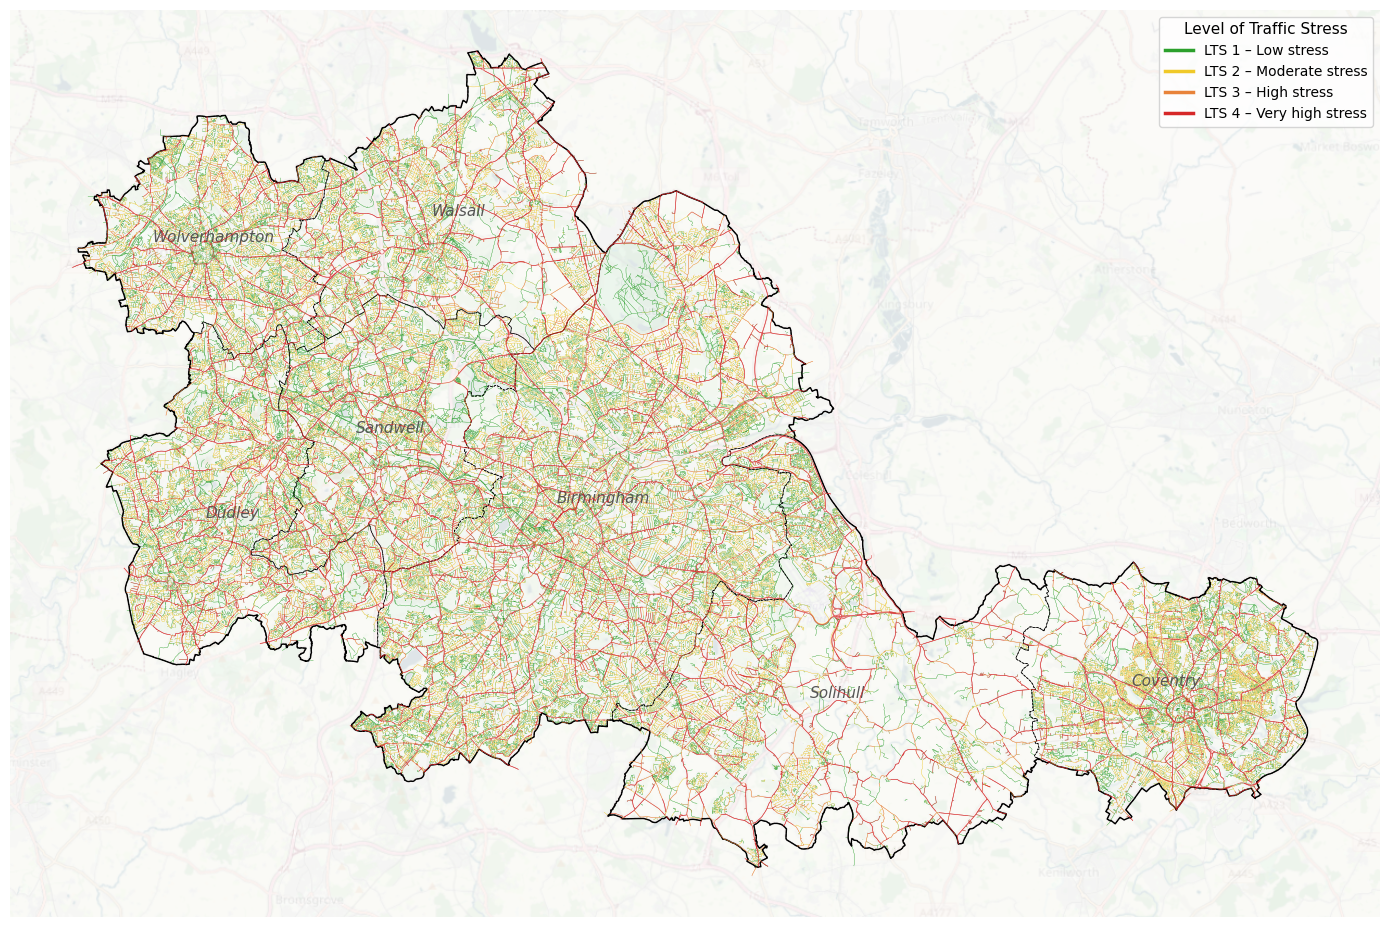

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

lts_colors = {1: '#2ca02c', 2: '#f0c929', 3: '#e8833a', 4: '#d62728'}
lts_labels = {1: 'LTS 1 \u2013 Low stress', 2: 'LTS 2 \u2013 Moderate stress',
              3: 'LTS 3 \u2013 High stress', 4: 'LTS 4 \u2013 Very high stress'}

fig, ax = plt.subplots(figsize=(14, 16))

# LTS 1
subset = network[network['lts_final'] == 1]
subset.plot(ax=ax, color=lts_colors[1], linewidth=0.2, alpha=0.8, zorder=1)

# LTS 2
subset = network[network['lts_final'] == 2]
subset.plot(ax=ax, color=lts_colors[2], linewidth=0.2, alpha=0.8, zorder=2)

# LTS 3
subset = network[network['lts_final'] == 3]
subset.plot(ax=ax, color=lts_colors[3], linewidth=0.3, alpha=0.8, zorder=3)

# LTS 4
subset = network[network['lts_final'] == 4]
subset.plot(ax=ax, color=lts_colors[4], linewidth=0.4, alpha=0.8, zorder=4)

legend_elements = [
    Line2D([0], [0], color=lts_colors[i], linewidth=2.5, label=lts_labels[i])
    for i in [1, 2, 3, 4]
]

study_area.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, linestyle='--')

gpd.GeoSeries([study_area_union], crs=study_area.crs).boundary.plot(
    ax=ax, edgecolor='black', linewidth=1, linestyle='-'
)

study_area.apply(lambda r: ax.annotate(
    text=r['LAD25NM'],
    xy=(r.geometry.centroid.x, r.geometry.centroid.y),
    ha='center', fontsize=11, color='#555555', fontstyle='italic'
), axis=1)

ax.legend(handles=legend_elements, loc='upper right', fontsize=10,
          frameon=True, facecolor='white', edgecolor='#cccccc',
          title='Level of Traffic Stress', title_fontsize=11)

# --- Basemap underneath (extent is now fixed, so tiles fetch correctly) ---
ctx.add_basemap(ax, crs=study_area.crs, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=11, alpha=0.6, attribution=False, zorder=0)
ctx.add_basemap(ax, crs=study_area.crs, source="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
                zoom=11, alpha=0.1, attribution=False, zorder=0)

ax.set_axis_off()
#ax.set_title('Level of Traffic Stress (Link-level Junction Enhancement)\nWest Midlands Cycling Network',fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
#plt.savefig("../Figure/wm_lts_classification.png", dpi=300, bbox_inches='tight')
plt.show()


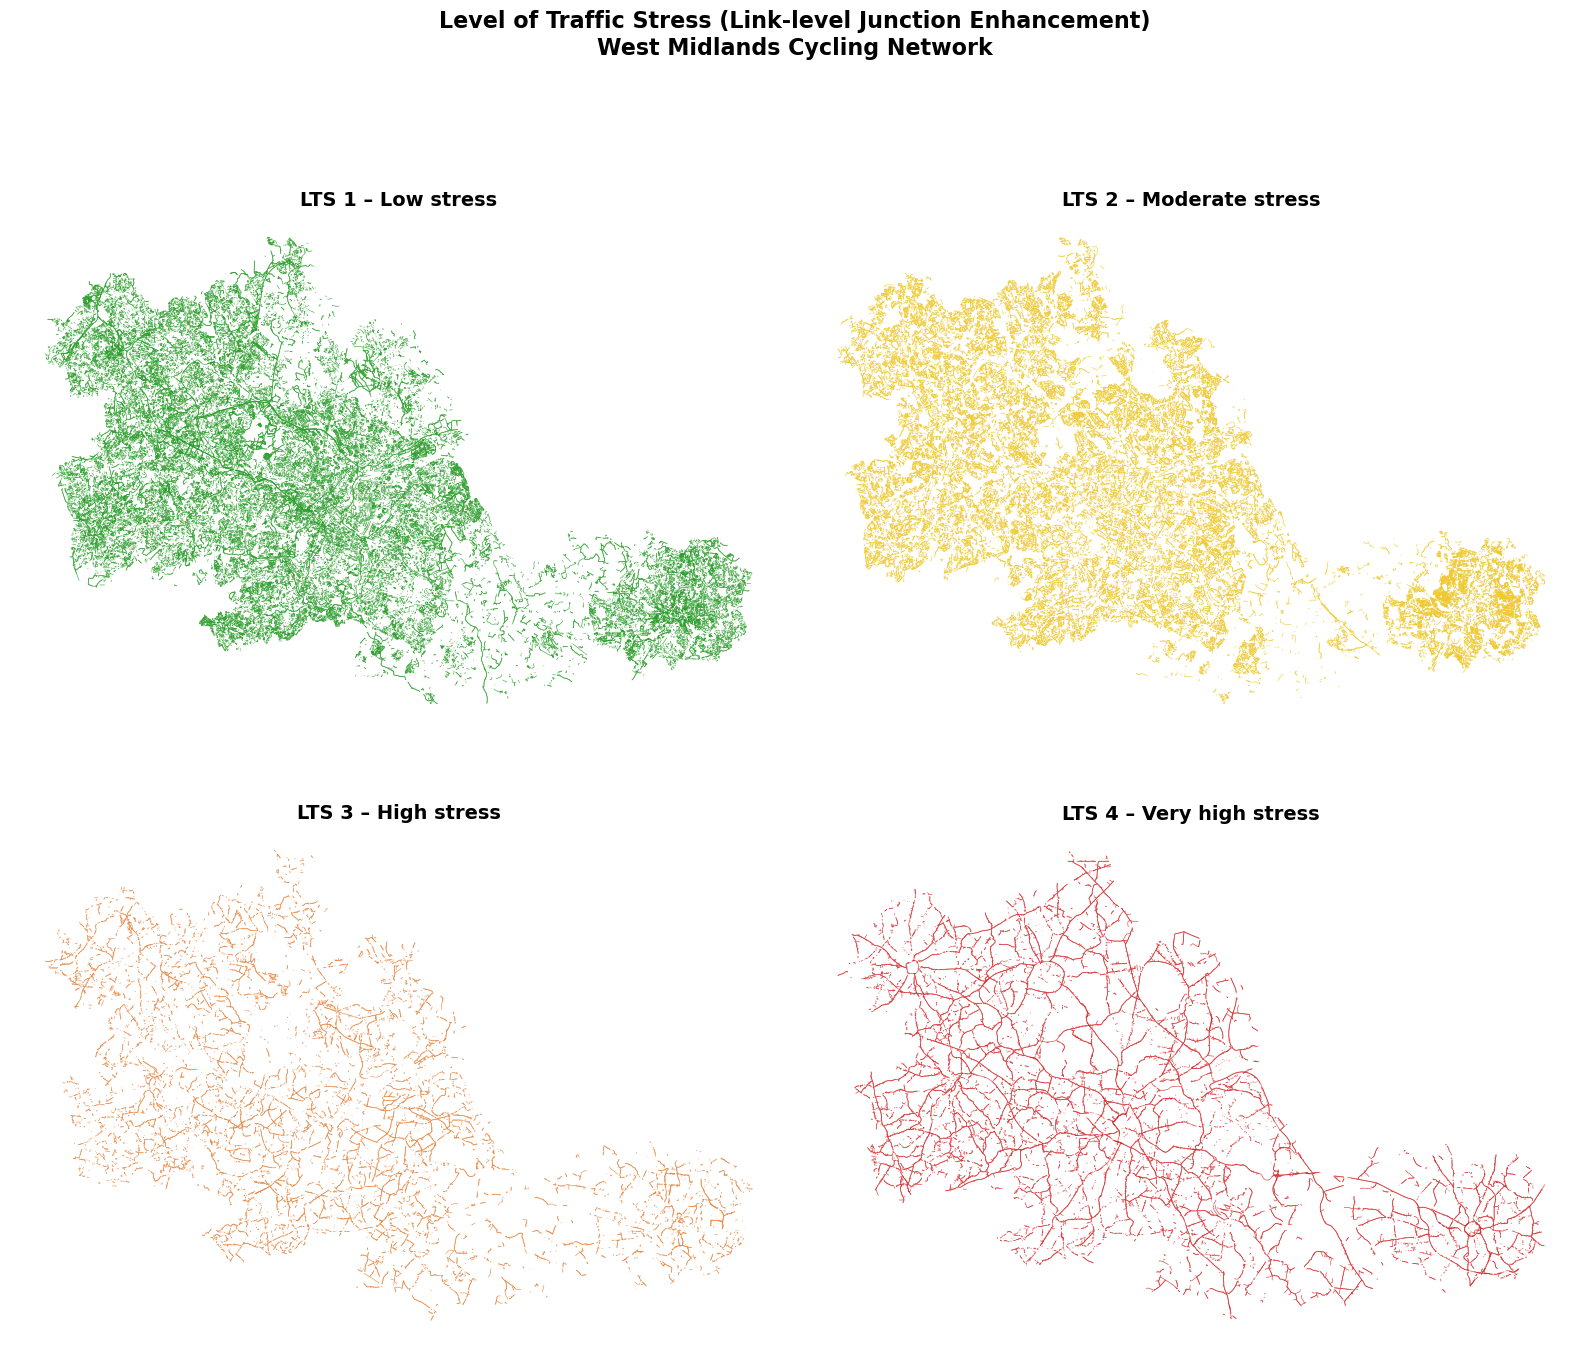

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

for i, lts in enumerate([1, 2, 3, 4]):
    ax = axes[i]
    subset = network[network['lts_final'] == lts]
    subset.plot(ax=ax, color=lts_colors[lts], linewidth=0.5, alpha=0.8)
    ax.set_title(lts_labels[lts], fontsize=14, fontweight='bold')
    ax.set_axis_off()

fig.suptitle('Level of Traffic Stress (Link-level Junction Enhancement)\nWest Midlands Cycling Network',
             fontsize=16, fontweight='bold', y=0.95)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 11. Export

Writes the junction-enhanced network and node table. `network_lts_with_junctions.gpkg`
retains both `lts` (link-level) and `lts_final` (junction-enhanced).

In [23]:
# Drop intermediate columns before export
drop_cols = [c for c in ['lts_junc_crossing', 'lts_junc_roundabout'] if c in network.columns]
network_export = network.drop(columns=drop_cols)

network_export.to_file(OUTPUT_DIR / "network_lts_with_junctions.gpkg", driver='GPKG')
nodes.to_file(OUTPUT_DIR / "network_nodes_jlts.gpkg", driver='GPKG')

print(f"Exported network: {len(network_export):,} directed edges")
print(f"Exported nodes: {len(nodes):,} nodes")
print(f"\nFinal LTS distribution:")
print(network_export['lts_final'].value_counts().sort_index())


Exported network: 480,228 directed edges
Exported nodes: 252,915 nodes

Final LTS distribution:
lts_final
1.0    227420
2.0    152180
3.0     46464
4.0     54164
Name: count, dtype: int64
